# Self-Supervised Learning: CLIP and DINOv2

In this notebook, we explore two powerful approaches to learning visual representations **without manual labels**:

1. **CLIP** (Contrastive Language-Image Pretraining) — aligns images and text in a shared embedding space using contrastive learning
2. **DINOv2** (Self-Distillation with No Labels v2) — learns universal visual features through a teacher-student framework

We use the **Pokemon BLIP Captions** dataset as our playground — Pokemon images paired with descriptive text captions.

**What you will learn:**
- How contrastive learning pulls matching image-text pairs together and pushes mismatches apart
- How to fine-tune CLIP on a custom dataset and track train/test loss
- How DINOv2 learns powerful visual features without any text supervision
- How to visualize and compare what each model learns
- When to use CLIP vs DINOv2

**Table of Contents:**
1. [Setup and Data](#setup)
2. [CLIP: Image-Text Alignment via Contrastive Learning](#clip)
3. [DINOv2: Self-Distillation for Visual Features](#dinov2)
4. [Comparison: CLIP vs DINOv2](#comparison)

In [4]:
# Uncomment the line below if running on Google Colab
# !pip install -q transformers datasets accelerate matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from datasets import load_dataset
from transformers import (
    CLIPModel, CLIPProcessor,
    AutoModel, AutoImageProcessor,
)
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


<a id="setup"></a>

## What Is Self-Supervised Learning?

Imagine you want to build an image search engine or a classifier, but you don't have labels for most of your data. **Self-supervised learning (SSL)** creates training signals from the data itself — no human annotation needed.

Instead of being told "this is a cat," SSL methods ask clever questions:
- *"Do these two views come from the same image?"* → contrastive learning
- *"Can the student network predict what the teacher sees?"* → self-distillation

The result is a powerful **encoder** — a model that converts raw pixels into meaningful feature vectors. Once trained, this encoder can be reused for many downstream tasks like classification, retrieval, and segmentation.

### Two Approaches We'll Compare

| | **CLIP** | **DINOv2** |
|---|---|---|
| **Learns from** | Image-text pairs | Multiple views of same image |
| **Method** | Contrastive learning | Self-distillation (teacher-student) |
| **Strength** | Connects vision and language | Strong general-purpose visual features |
| **Best for** | Text-based image search, zero-shot classification | Image retrieval, segmentation, linear probing |

## Load and Explore the Pokemon Dataset

Our dataset contains **833 Pokemon images**, each with a descriptive caption generated by BLIP (a vision-language model). This gives us:
- **Paired image-text data** — perfect for CLIP's contrastive learning
- **Diverse images** — ideal for DINOv2's visual feature learning

Loading Pokemon BLIP Captions dataset...


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

data/train-00000-of-00001-566cc9b19d7203(…):   0%|          | 0.00/99.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

Dataset size: 833 images
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}

Sample captions:
  [0] a drawing of a green pokemon with red eyes
  [1] a green and yellow toy with a red nose
  [2] a red and white ball with an angry look on its face
  [3] a cartoon ball with a smile on it's face
  [4] a bunch of balls with faces drawn on them


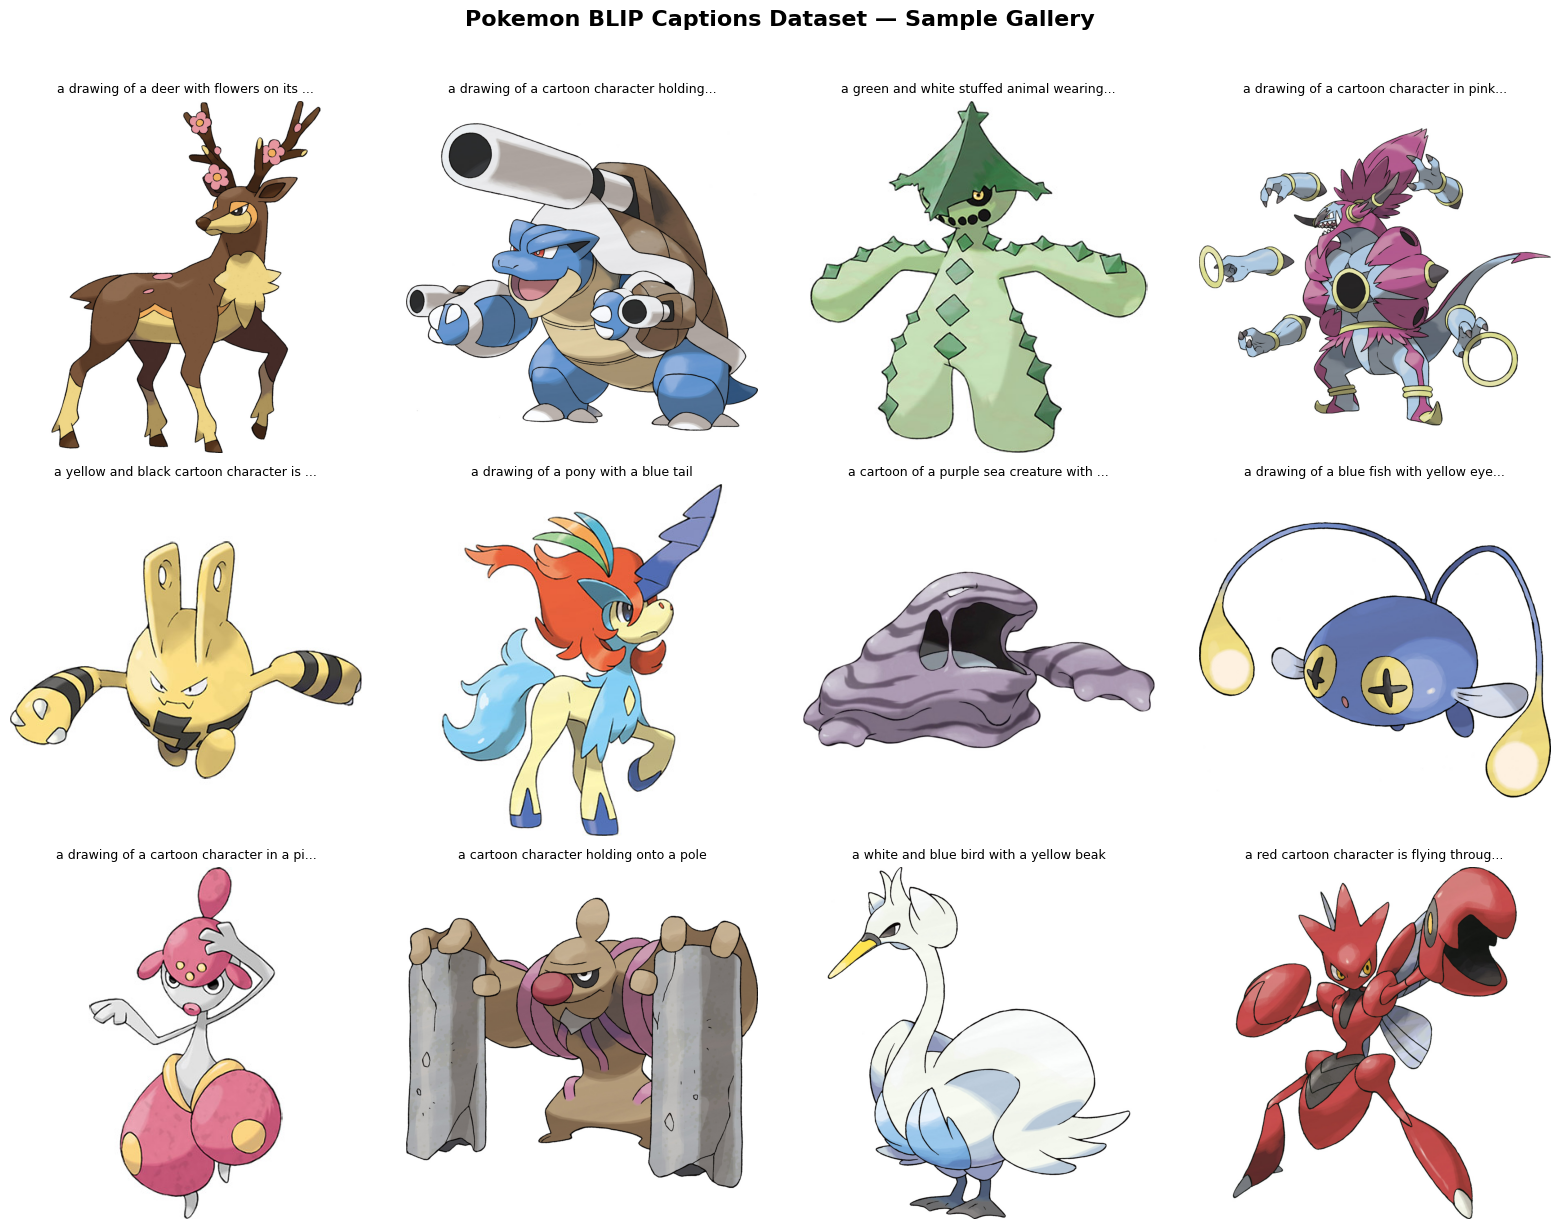

In [5]:
# Load Pokemon BLIP Captions dataset
print("Loading Pokemon BLIP Captions dataset...")
full_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")
print(f"Dataset size: {len(full_dataset)} images")
print(f"Features: {full_dataset.features}")
print(f"\nSample captions:")
for i in range(5):
    print(f"  [{i}] {full_dataset[i]['text']}")

# Visualize a gallery
np.random.seed(42)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
indices = np.random.choice(len(full_dataset), 12, replace=False)

for ax, idx in zip(axes.flat, indices):
    item = full_dataset[int(idx)]
    ax.imshow(item['image'].convert('RGB'))
    caption = item['text']
    ax.set_title(caption[:40] + "..." if len(caption) > 40 else caption, fontsize=9)
    ax.axis('off')

plt.suptitle('Pokemon BLIP Captions Dataset — Sample Gallery',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id="clip"></a>

---

# Part 1: CLIP — Contrastive Language-Image Pretraining

## The Big Idea

CLIP learns by **comparison**. Given a batch of image-text pairs, it trains two encoders simultaneously:
- An **image encoder** (Vision Transformer) that maps images to feature vectors
- A **text encoder** (Transformer) that maps captions to feature vectors

The training rule is simple:
- **Matching pairs** (image $i$ + caption $i$) → push their embeddings **close together**
- **Non-matching pairs** (image $i$ + caption $j$) → push their embeddings **far apart**

```
  "a blue pokemon"  ──→ [Text Encoder]  ──→ text embedding  ─┐
                                                               ├─ Should be similar!
  🖼️ blue pokemon   ──→ [Image Encoder] ──→ image embedding ─┘
```

## The CLIP Loss

Given a batch of $N$ image-text pairs, CLIP builds an $N \times N$ similarity matrix. Entry $(i, j)$ measures how similar image $i$ is to text $j$. The correct matches sit on the diagonal.

$$\mathcal{L}_{\text{CLIP}} = \frac{1}{2}\left(\mathcal{L}_{\text{image} \to \text{text}} + \mathcal{L}_{\text{text} \to \text{image}}\right)$$

Each direction is a cross-entropy loss: every image should "pick" its correct caption out of all $N$ options, and every caption should "pick" its correct image.

## Why CLIP Is Powerful

Because CLIP aligns images with **free-form text** (not fixed class labels), it learns very rich visual concepts. This enables **zero-shot classification** — classifying images into categories it was never explicitly trained on, simply by comparing to text descriptions.

In [6]:
# Load pretrained CLIP (ViT-B/32)
print("Loading CLIP ViT-B/32...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

n_img = sum(p.numel() for p in clip_model.vision_model.parameters())
n_txt = sum(p.numel() for p in clip_model.text_model.parameters())
print(f"Image encoder: {n_img / 1e6:.1f}M parameters")
print(f"Text encoder:  {n_txt / 1e6:.1f}M parameters")
print(f"Total:         {sum(p.numel() for p in clip_model.parameters()) / 1e6:.1f}M parameters")

Loading CLIP ViT-B/32...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Image encoder: 87.5M parameters
Text encoder:  63.2M parameters
Total:         151.3M parameters


### Zero-Shot Classification with CLIP

One of CLIP's most impressive abilities: classify images into categories **it was never trained on**.

The trick:
1. Write a text prompt for each category (e.g., "a drawing of a blue water creature")
2. Encode all prompts with the text encoder
3. Encode the image with the image encoder
4. Pick the prompt whose embedding is most similar to the image

No training needed — just inference!

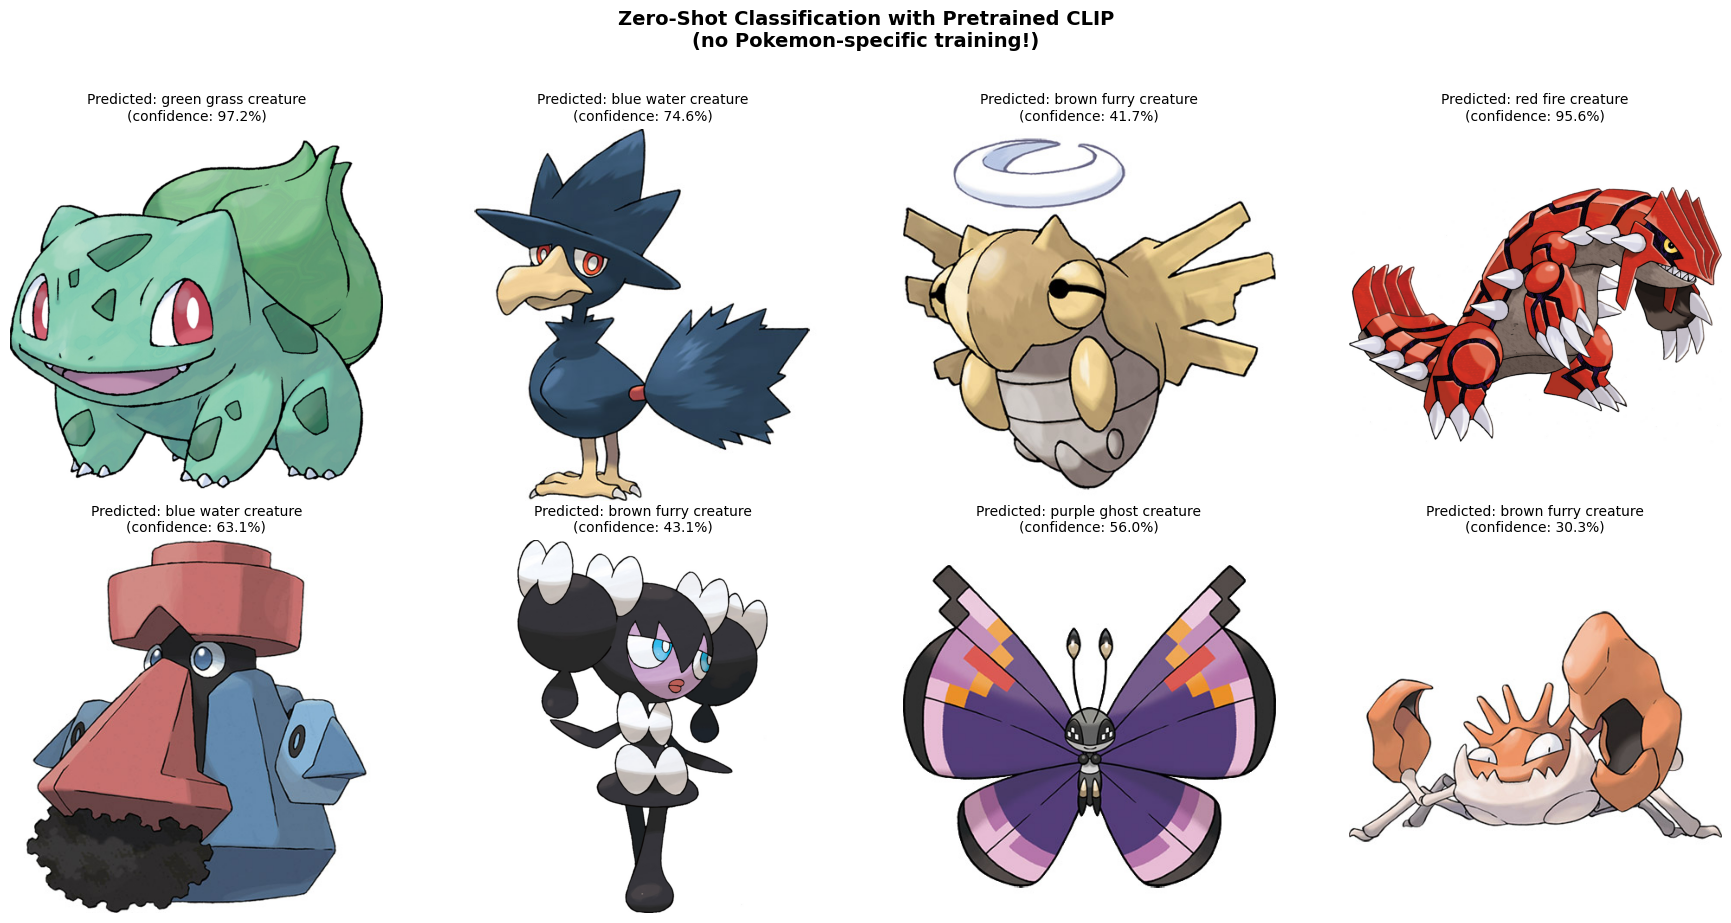

In [7]:
# Zero-shot classification on Pokemon
candidate_labels = [
    "a drawing of a blue water creature",
    "a drawing of a red fire creature",
    "a drawing of a green grass creature",
    "a drawing of a yellow electric creature",
    "a drawing of a purple ghost creature",
    "a drawing of a brown furry creature",
    "a drawing of a pink cute creature",
    "a drawing of a white ice creature",
]

# Pick 8 evenly spaced Pokemon
sample_indices = np.linspace(0, len(full_dataset) - 1, 8, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
clip_model.eval()

for ax, idx in zip(axes.flat, sample_indices):
    item = full_dataset[int(idx)]
    image = item['image'].convert('RGB')

    inputs = clip_processor(
        text=candidate_labels, images=image,
        return_tensors="pt", padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=-1)[0].cpu().numpy()

    top_idx = probs.argmax()
    short_label = candidate_labels[top_idx].replace("a drawing of a ", "")

    ax.imshow(image)
    ax.set_title(f"Predicted: {short_label}\n(confidence: {probs[top_idx]:.1%})", fontsize=10)
    ax.axis('off')

plt.suptitle('Zero-Shot Classification with Pretrained CLIP\n(no Pokemon-specific training!)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Visualizing the Image-Text Similarity Matrix

The core of CLIP is the similarity matrix between image and text embeddings. Let's visualize this directly — we encode a batch of images and their captions, then compute all pairwise cosine similarities.

In a well-aligned model, the **diagonal** (correct matches) should dominate each row and column.

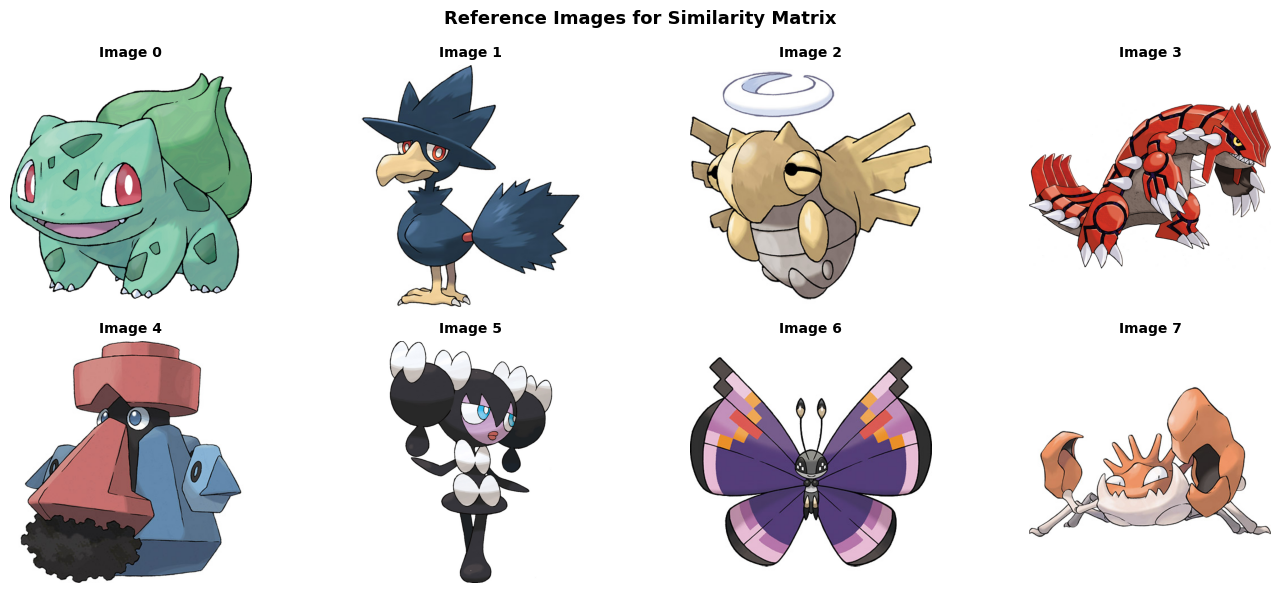

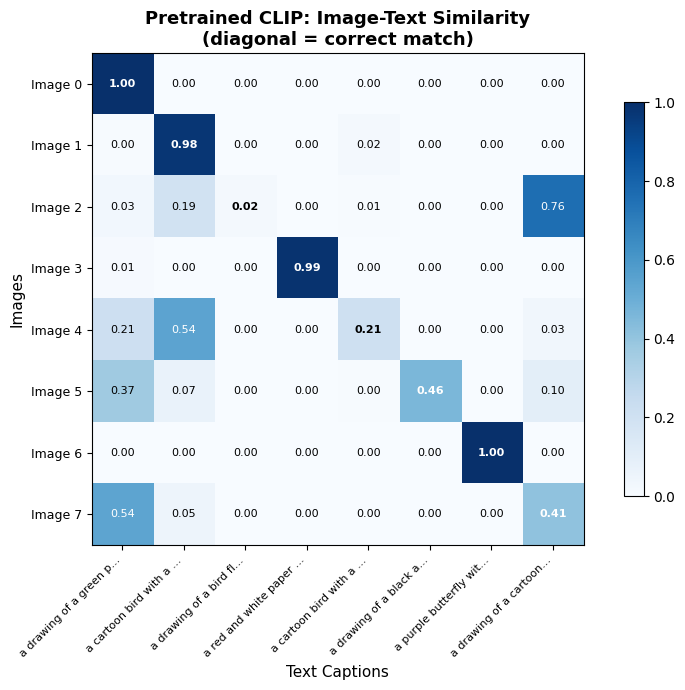

In [8]:
# Build and visualize the image-text similarity matrix
n_vis = 8
vis_indices = np.linspace(0, len(full_dataset) - 1, n_vis, dtype=int)

vis_images = []
vis_captions = []
for idx in vis_indices:
    item = full_dataset[int(idx)]
    vis_images.append(item['image'].convert('RGB'))
    vis_captions.append(item['text'])

inputs = clip_processor(
    text=vis_captions, images=vis_images,
    return_tensors="pt", padding=True, truncation=True
).to(device)

clip_model.eval()
with torch.no_grad():
    outputs = clip_model(**inputs)
    logits_pre = outputs.logits_per_image.cpu()

probs_pre = logits_pre.softmax(dim=-1).numpy()

# Show the reference images
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, (ax, img) in enumerate(zip(axes.flat, vis_images)):
    ax.imshow(img)
    ax.set_title(f"Image {i}", fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle("Reference Images for Similarity Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Show the similarity matrix
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(probs_pre, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_vis))
ax.set_yticks(range(n_vis))
short_caps = [c[:22] + "..." if len(c) > 22 else c for c in vis_captions]
ax.set_xticklabels(short_caps, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([f"Image {i}" for i in range(n_vis)], fontsize=9)
ax.set_title("Pretrained CLIP: Image-Text Similarity\n(diagonal = correct match)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Text Captions", fontsize=11)
ax.set_ylabel("Images", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)

for i in range(n_vis):
    for j in range(n_vis):
        color = 'white' if probs_pre[i, j] > 0.4 else 'black'
        ax.text(j, i, f"{probs_pre[i, j]:.2f}", ha='center', va='center',
                fontsize=8, color=color, fontweight='bold' if i == j else 'normal')

plt.tight_layout()
plt.show()

## Fine-Tuning CLIP on Pokemon

Pretrained CLIP has general visual knowledge, but it hasn't seen our specific Pokemon captions. Let's fine-tune it so the model better connects Pokemon images with their descriptions.

**Our plan:**
1. Split the dataset into **train (80%)** and **test (20%)**
2. Fine-tune the entire CLIP model using the contrastive loss
3. Track both **train loss** and **test loss** to monitor learning and overfitting
4. Compare the results before and after fine-tuning

The contrastive loss is built into the `CLIPModel` — we just pass `return_loss=True` and the model handles everything.

In [9]:
# Train/test split
np.random.seed(42)
all_indices = np.arange(len(full_dataset))
np.random.shuffle(all_indices)
train_size = int(0.8 * len(full_dataset))
train_indices = all_indices[:train_size].tolist()
test_indices = all_indices[train_size:].tolist()

train_dataset = full_dataset.select(train_indices)
test_dataset = full_dataset.select(test_indices)
print(f"Train: {len(train_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

# Collate function: turns a list of dataset items into a batch of tensors
def clip_collate_fn(batch):
    images = [item['image'].convert('RGB') for item in batch]
    texts = [item['text'] for item in batch]
    return clip_processor(
        text=texts, images=images,
        return_tensors="pt", padding=True, truncation=True
    )

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=clip_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=clip_collate_fn)
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train: 666 images
Test:  167 images
Train batches per epoch: 21
Test batches: 6


In [10]:
# Fine-tune CLIP on Pokemon
torch.manual_seed(42)
optimizer = torch.optim.AdamW(clip_model.parameters(), lr=1e-5, weight_decay=0.01)

num_epochs = 10
clip_train_losses = []
clip_test_losses = []

for epoch in range(num_epochs):
    # --- Training ---
    clip_model.train()
    total_train_loss = 0
    n_train = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = clip_model(**batch, return_loss=True)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        n_train += 1

    avg_train = total_train_loss / n_train
    clip_train_losses.append(avg_train)

    # --- Evaluation ---
    clip_model.eval()
    total_test_loss = 0
    n_test = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = clip_model(**batch, return_loss=True)
            total_test_loss += outputs.loss.item()
            n_test += 1

    avg_test = total_test_loss / n_test
    clip_test_losses.append(avg_test)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {avg_train:.4f} | Test Loss: {avg_test:.4f}")

print("\nCLIP fine-tuning complete!")

Epoch  1/10 | Train Loss: 1.1288 | Test Loss: 0.8729
Epoch  2/10 | Train Loss: 0.3069 | Test Loss: 0.9843
Epoch  3/10 | Train Loss: 0.1680 | Test Loss: 1.0693
Epoch  4/10 | Train Loss: 0.0996 | Test Loss: 1.0557
Epoch  5/10 | Train Loss: 0.0948 | Test Loss: 1.0594
Epoch  6/10 | Train Loss: 0.0883 | Test Loss: 1.1648
Epoch  7/10 | Train Loss: 0.0847 | Test Loss: 1.0659
Epoch  8/10 | Train Loss: 0.0771 | Test Loss: 0.9805
Epoch  9/10 | Train Loss: 0.0732 | Test Loss: 1.0776
Epoch 10/10 | Train Loss: 0.0736 | Test Loss: 1.0648

CLIP fine-tuning complete!


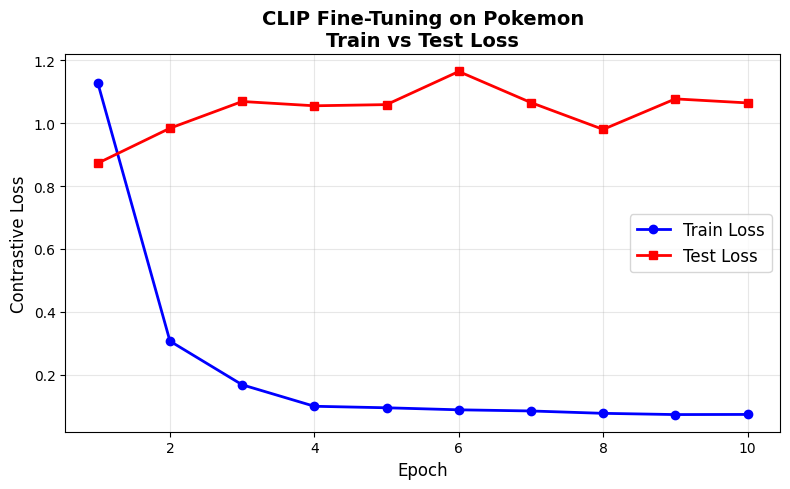

In [11]:
# Plot CLIP training curves
fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, num_epochs + 1)
ax.plot(epochs_range, clip_train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs_range, clip_test_losses, 'r-s', label='Test Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Contrastive Loss', fontsize=12)
ax.set_title('CLIP Fine-Tuning on Pokemon\nTrain vs Test Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluating the Fine-Tuned Model

Let's see how fine-tuning changed CLIP's behavior:
1. **Similarity matrix** — the diagonal should be stronger (better matching)
2. **Text-to-image retrieval** — given a text query, find the most relevant Pokemon images

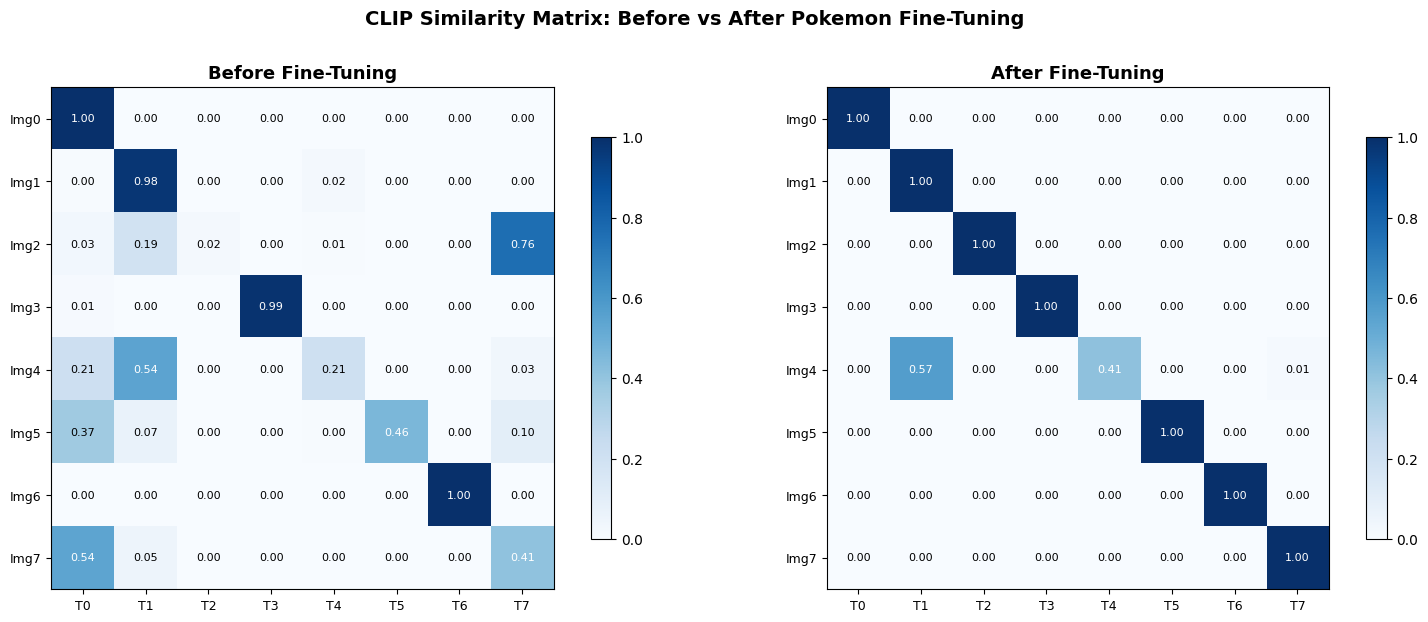

In [12]:
# Re-compute similarity matrix with the SAME images (for fair comparison)
inputs = clip_processor(
    text=vis_captions, images=vis_images,
    return_tensors="pt", padding=True, truncation=True
).to(device)

clip_model.eval()
with torch.no_grad():
    outputs = clip_model(**inputs)
    logits_ft = outputs.logits_per_image.cpu()

probs_ft = logits_ft.softmax(dim=-1).numpy()

# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, p, title in [(ax1, probs_pre, "Before Fine-Tuning"),
                      (ax2, probs_ft, "After Fine-Tuning")]:
    im = ax.imshow(p, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n_vis))
    ax.set_yticks(range(n_vis))
    ax.set_xticklabels([f"T{i}" for i in range(n_vis)], fontsize=9)
    ax.set_yticklabels([f"Img{i}" for i in range(n_vis)], fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(n_vis):
        for j in range(n_vis):
            color = 'white' if p[i, j] > 0.4 else 'black'
            ax.text(j, i, f"{p[i, j]:.2f}", ha='center', va='center',
                    fontsize=8, color=color)

plt.suptitle("CLIP Similarity Matrix: Before vs After Pokemon Fine-Tuning",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Encoding all images with fine-tuned CLIP...
CLIP image features: torch.Size([833, 512])


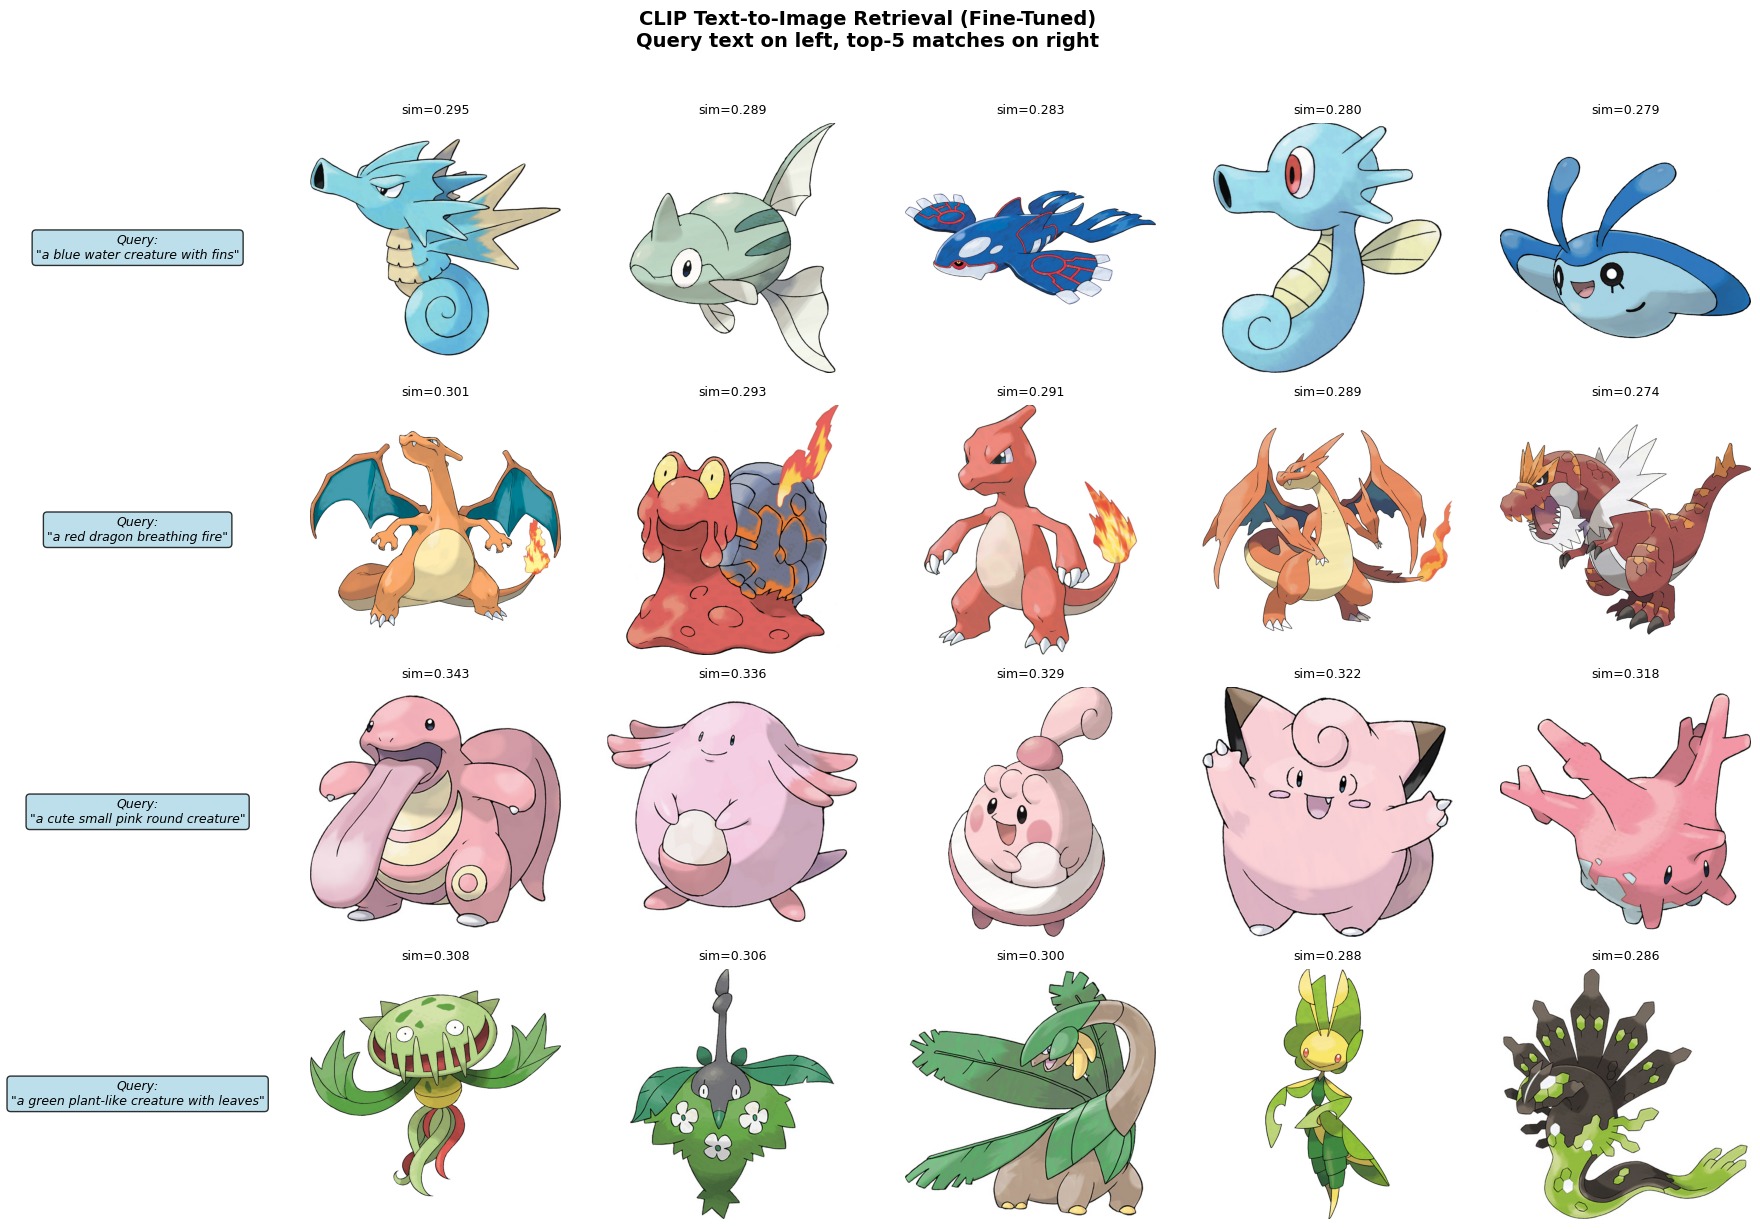

In [14]:
# Text-to-image retrieval with fine-tuned CLIP
# First, encode all images
print("Encoding all images with fine-tuned CLIP...")
all_clip_features = []
clip_model.eval()

with torch.no_grad():
    for i in range(0, len(full_dataset), 64):
        batch_end = min(i + 64, len(full_dataset))
        images = [full_dataset[j]['image'].convert('RGB') for j in range(i, batch_end)]
        inputs = clip_processor(images=images, return_tensors="pt").to(device)
        feats = clip_model.get_image_features(**inputs)
        if not isinstance(feats, torch.Tensor):
            feats = feats.pooler_output
        feats = F.normalize(feats, dim=-1)
        all_clip_features.append(feats.cpu())

all_clip_features = torch.cat(all_clip_features, dim=0)
print(f"CLIP image features: {all_clip_features.shape}")

# Text queries → find best matching Pokemon
queries = [
    "a blue water creature with fins",
    "a red dragon breathing fire",
    "a cute small pink round creature",
    "a green plant-like creature with leaves",
]

fig, axes = plt.subplots(len(queries), 6, figsize=(18, 3 * len(queries)))

for row, query in enumerate(queries):
    # Encode query text
    text_inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_feat = clip_model.get_text_features(**text_inputs)
        if not isinstance(text_feat, torch.Tensor):
            text_feat = text_feat.pooler_output
        text_feat = F.normalize(text_feat, dim=-1)

    # Find top-5 matches
    sims = (text_feat.cpu() @ all_clip_features.T)[0]
    top5 = sims.topk(5).indices.tolist()

    # Show query text
    axes[row, 0].text(0.5, 0.5, f'Query:\n"{query}"',
                      ha='center', va='center', fontsize=9, style='italic',
                      transform=axes[row, 0].transAxes,
                      bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[row, 0].axis('off')

    # Show retrieved images
    for col, idx in enumerate(top5):
        axes[row, col + 1].imshow(full_dataset[idx]['image'].convert('RGB'))
        axes[row, col + 1].set_title(f"sim={sims[idx]:.3f}", fontsize=9)
        axes[row, col + 1].axis('off')

plt.suptitle("CLIP Text-to-Image Retrieval (Fine-Tuned)\nQuery text on left, top-5 matches on right",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id="dinov2"></a>

---

# Part 2: DINOv2 — Self-Distillation for Visual Features

## A Different Philosophy

While CLIP needs image-text pairs, DINOv2 learns entirely from **images alone**. It uses a clever **teacher-student** framework:

1. Take one image and create **multiple crops** (views) — some large (global), some small (local)
2. A **teacher** network processes the global crops and produces target representations
3. A **student** network processes all crops and tries to **match the teacher's output**
4. The teacher is updated as a slow-moving average of the student (not by gradient descent!)

$$\theta_{\text{teacher}} \leftarrow \lambda \cdot \theta_{\text{teacher}} + (1 - \lambda) \cdot \theta_{\text{student}}$$

This **exponential moving average (EMA)** creates a stable target that prevents the model from collapsing (where everything maps to the same boring embedding).

## Why DINOv2 Features Are Special

DINOv2 produces remarkably strong visual features that transfer well to many tasks:
- **Image retrieval** — find visually similar images without any text
- **Classification** — a simple linear layer on frozen features achieves strong accuracy
- **Attention maps** — DINOv2 naturally "looks at" the most important parts of each image
- **Dense tasks** — patch-level features support segmentation and depth estimation

The key insight from the self-supervised learning literature:

> **A strong encoder trained on diverse images can be reused everywhere — without needing text or labels.**

In [18]:
# Load DINOv2-small
# Use attn_implementation="eager" so we can extract attention maps later
print("Loading DINOv2-small...")
dino_model = AutoModel.from_pretrained("facebook/dinov2-small", attn_implementation="eager").to(device)
dino_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dino_model.eval()

n_params = sum(p.numel() for p in dino_model.parameters())
print(f"DINOv2-small: {n_params / 1e6:.1f}M parameters")
print(f"Hidden dimension: {dino_model.config.hidden_size}")
print(f"Patch size: {dino_model.config.patch_size}")

# Extract CLS features for all images
print("\nExtracting DINOv2 features for all images...")
all_dino_features = []

with torch.no_grad():
    for i in range(0, len(full_dataset), 32):
        batch_end = min(i + 32, len(full_dataset))
        images = [full_dataset[j]['image'].convert('RGB') for j in range(i, batch_end)]
        inputs = dino_processor(images=images, return_tensors="pt").to(device)
        outputs = dino_model(**inputs)
        # Use CLS token (first token) as global image feature
        cls_features = outputs.last_hidden_state[:, 0]
        all_dino_features.append(cls_features.cpu())

all_dino_features = torch.cat(all_dino_features, dim=0)
print(f"DINOv2 features shape: {all_dino_features.shape}")

Loading DINOv2-small...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2-small: 22.1M parameters
Hidden dimension: 384
Patch size: 14

Extracting DINOv2 features for all images...
DINOv2 features shape: torch.Size([833, 384])


### Visualizing DINOv2's Learned Feature Space

Even though DINOv2 never sees text, it should organize images by **visual similarity**. Let's project the high-dimensional features to 2D using **t-SNE** and color points by the dominant color mentioned in each caption.

If DINOv2 has learned good representations, visually similar Pokemon should cluster together.

Running t-SNE on DINOv2 features (this may take a minute)...


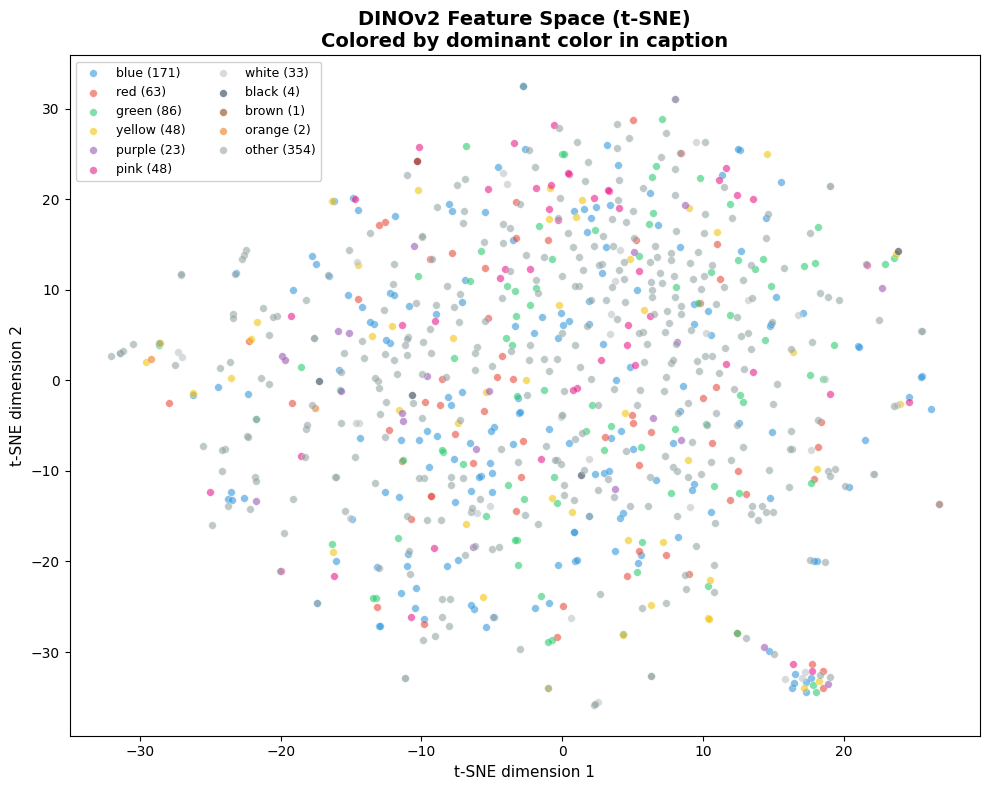

In [19]:
# Extract color labels from captions for visualization
color_map = {
    'blue': '#3498db', 'red': '#e74c3c', 'green': '#2ecc71',
    'yellow': '#f1c40f', 'purple': '#9b59b6', 'pink': '#e91e8a',
    'white': '#bdc3c7', 'black': '#2c3e50', 'brown': '#8b4513',
    'orange': '#e67e22',
}

color_labels = []
for item in full_dataset:
    caption = item['text'].lower()
    found = 'other'
    for keyword in color_map:
        if keyword in caption:
            found = keyword
            break
    color_labels.append(found)

# t-SNE projection
print("Running t-SNE on DINOv2 features (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
dino_2d = tsne.fit_transform(all_dino_features.numpy())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
for color_name in list(color_map.keys()) + ['other']:
    hex_color = color_map.get(color_name, '#95a5a6')
    mask = np.array([c == color_name for c in color_labels])
    n = mask.sum()
    if n > 0:
        ax.scatter(dino_2d[mask, 0], dino_2d[mask, 1], c=hex_color,
                   label=f"{color_name} ({n})", alpha=0.6, s=30,
                   edgecolors='white', linewidth=0.3)

ax.set_title("DINOv2 Feature Space (t-SNE)\nColored by dominant color in caption",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='best', ncol=2, framealpha=0.9)
ax.set_xlabel("t-SNE dimension 1", fontsize=11)
ax.set_ylabel("t-SNE dimension 2", fontsize=11)
plt.tight_layout()
plt.show()

### DINOv2 Attention Maps

One of the most impressive properties of DINO-style models: the attention heads naturally learn to **focus on the main object** in each image. The CLS token's attention to each patch tells us where the model is "looking."

Let's visualize this for several Pokemon images.

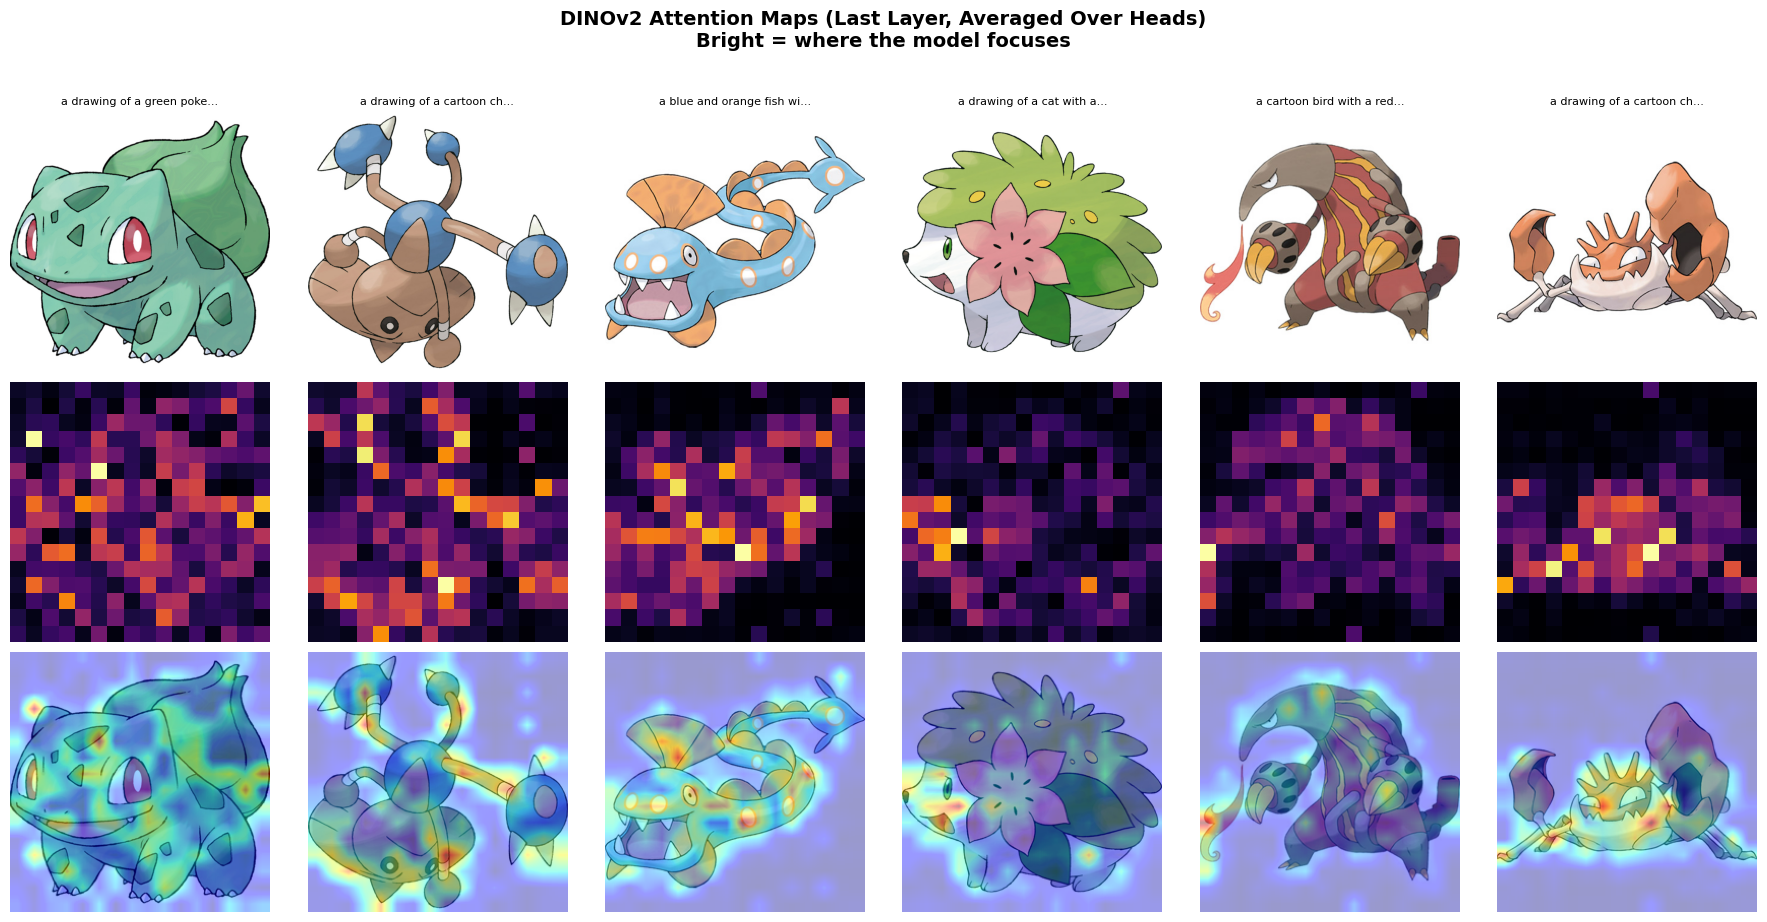

In [20]:
# Visualize DINOv2 attention maps
attn_indices = np.linspace(0, len(full_dataset) - 1, 6, dtype=int)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for col, idx in enumerate(attn_indices):
    image = full_dataset[int(idx)]['image'].convert('RGB')
    caption = full_dataset[int(idx)]['text']

    inputs = dino_processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs, output_attentions=True)

    # Last layer attention: CLS token → all patches
    attn = outputs.attentions[-1][0]  # (heads, seq_len, seq_len)
    cls_attn = attn[:, 0, 1:].mean(dim=0)  # average over heads, skip CLS→CLS

    # Reshape to spatial grid
    n_patches = cls_attn.shape[0]
    grid_size = int(n_patches ** 0.5)
    attn_map = cls_attn.cpu().numpy()[:grid_size * grid_size].reshape(grid_size, grid_size)

    # Row 0: Original image
    axes[0, col].imshow(image)
    short_cap = caption[:25] + "..." if len(caption) > 25 else caption
    axes[0, col].set_title(short_cap, fontsize=8)
    axes[0, col].axis('off')

    # Row 1: Attention heatmap
    axes[1, col].imshow(attn_map, cmap='inferno')
    axes[1, col].axis('off')

    # Row 2: Overlay attention on image
    display_size = 256
    img_resized = np.array(image.resize((display_size, display_size)))
    attn_uint8 = (attn_map / attn_map.max() * 255).astype(np.uint8)
    attn_resized = np.array(
        PILImage.fromarray(attn_uint8).resize((display_size, display_size), PILImage.BILINEAR)
    )
    axes[2, col].imshow(img_resized)
    axes[2, col].imshow(attn_resized, cmap='jet', alpha=0.4)
    axes[2, col].axis('off')

# Row labels
for row, label in enumerate(["Original", "Attention Map", "Overlay"]):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold')

plt.suptitle("DINOv2 Attention Maps (Last Layer, Averaged Over Heads)\nBright = where the model focuses",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

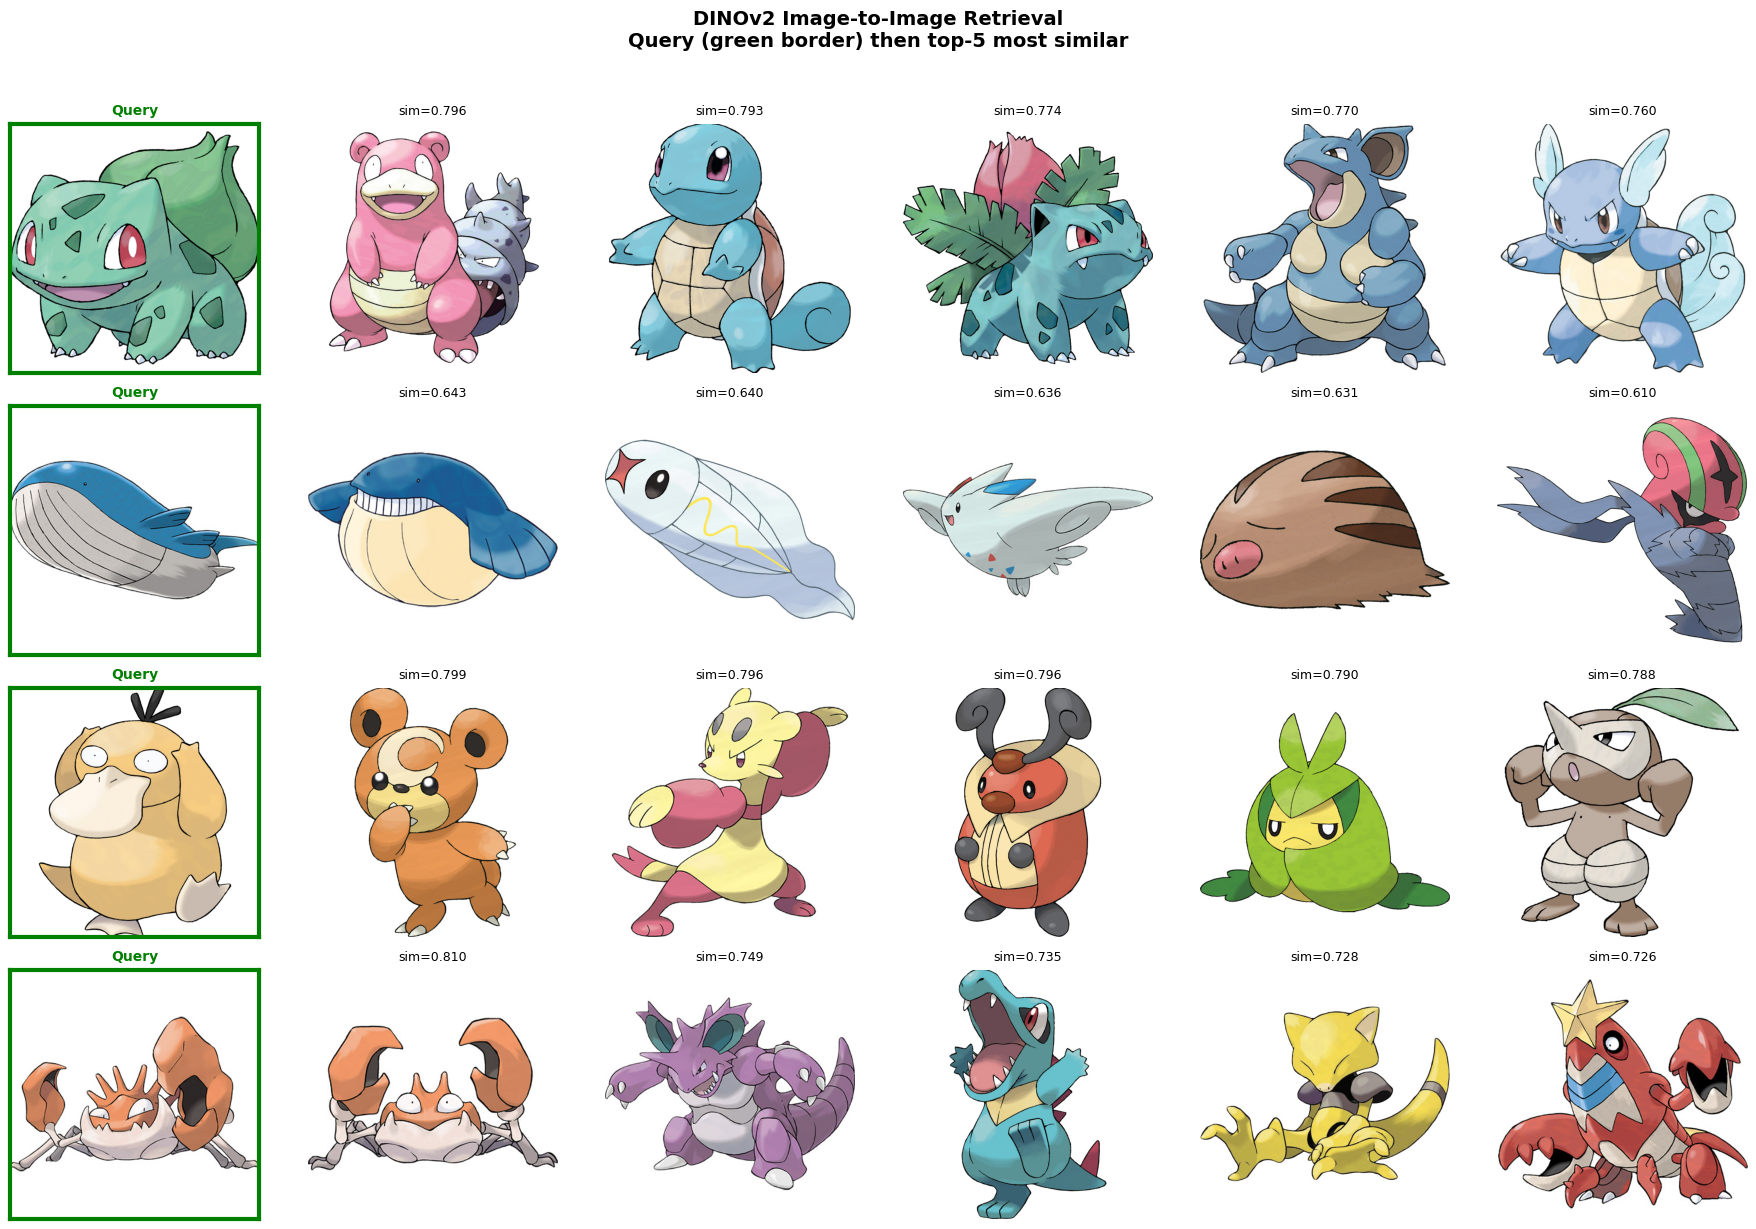

In [21]:
# Image-to-image retrieval with DINOv2
# Given a query Pokemon, find the most visually similar ones

def retrieve_similar(query_idx, features, k=5):
    # Find k most similar images by cosine similarity
    query = features[query_idx]
    sims = F.cosine_similarity(query.unsqueeze(0), features)
    sims[query_idx] = -1  # exclude self
    top_k = sims.topk(k)
    return top_k.indices.tolist(), top_k.values.tolist()

query_indices = np.linspace(0, len(full_dataset) - 1, 4, dtype=int)

fig, axes = plt.subplots(len(query_indices), 6, figsize=(18, 3 * len(query_indices)))

for row, q_idx in enumerate(query_indices):
    q_item = full_dataset[int(q_idx)]

    # Query image with green border
    axes[row, 0].imshow(q_item['image'].convert('RGB'))
    axes[row, 0].set_title("Query", fontsize=10, fontweight='bold', color='green')
    for spine in axes[row, 0].spines.values():
        spine.set_visible(True)
        spine.set_color('green')
        spine.set_linewidth(3)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    # Retrieved images
    ret_indices, ret_sims = retrieve_similar(int(q_idx), all_dino_features)
    for col, (r_idx, sim) in enumerate(zip(ret_indices, ret_sims)):
        axes[row, col + 1].imshow(full_dataset[r_idx]['image'].convert('RGB'))
        axes[row, col + 1].set_title(f"sim={sim:.3f}", fontsize=9)
        axes[row, col + 1].axis('off')

plt.suptitle("DINOv2 Image-to-Image Retrieval\nQuery (green border) then top-5 most similar",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Linear Probing: Testing the Quality of Frozen Features

A classic test of how good an encoder is: **freeze the encoder, extract features, and train only a simple linear classifier on top.**

If a linear classifier achieves good accuracy, it means the encoder has already organized the feature space meaningfully — visually similar concepts are close together, different concepts are far apart.

We'll use DINOv2 features to predict the **dominant color** mentioned in each Pokemon's caption. This tests whether DINOv2 captures color information purely from visual patterns (remember: DINOv2 never saw the text!).

In [22]:
# Prepare color classification labels from captions
color_categories = ['blue', 'red', 'green', 'yellow', 'purple',
                    'pink', 'white', 'black', 'brown', 'orange']

labels = []
for item in full_dataset:
    caption = item['text'].lower()
    found = len(color_categories)  # "other" class
    for i, c in enumerate(color_categories):
        if c in caption:
            found = i
            break
    labels.append(found)

labels = torch.tensor(labels)
n_classes = len(color_categories) + 1

# Show class distribution
print("Color label distribution:")
for i, name in enumerate(color_categories + ['other']):
    count = (labels == i).sum().item()
    if count > 0:
        print(f"  {name:>8s}: {count:3d} ({count/len(labels):.1%})")

# Split features using same indices as CLIP
train_feats = all_dino_features[train_indices]
train_labels = labels[train_indices]
test_feats = all_dino_features[test_indices]
test_labels = labels[test_indices]

# Train a simple linear classifier
torch.manual_seed(42)
classifier = nn.Linear(all_dino_features.shape[1], n_classes).to(device)
clf_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

n_probe_epochs = 100
dino_train_losses = []
dino_test_losses = []

for epoch in range(n_probe_epochs):
    # Train
    classifier.train()
    logits = classifier(train_feats.to(device))
    loss = F.cross_entropy(logits, train_labels.to(device))
    clf_optimizer.zero_grad()
    loss.backward()
    clf_optimizer.step()
    dino_train_losses.append(loss.item())

    # Test
    classifier.eval()
    with torch.no_grad():
        test_logits = classifier(test_feats.to(device))
        test_loss = F.cross_entropy(test_logits, test_labels.to(device))
    dino_test_losses.append(test_loss.item())

    if (epoch + 1) % 20 == 0:
        train_acc = (logits.argmax(-1) == train_labels.to(device)).float().mean()
        test_acc = (test_logits.argmax(-1) == test_labels.to(device)).float().mean()
        print(f"Epoch {epoch+1:3d}/{n_probe_epochs} | "
              f"Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"Train Acc: {train_acc:.1%} | Test Acc: {test_acc:.1%}")

# Final test accuracy
classifier.eval()
with torch.no_grad():
    final_preds = classifier(test_feats.to(device)).argmax(-1).cpu()
    final_acc = (final_preds == test_labels).float().mean()
print(f"\nFinal Test Accuracy: {final_acc:.1%}")

Color label distribution:
      blue: 171 (20.5%)
       red:  63 (7.6%)
     green:  86 (10.3%)
    yellow:  48 (5.8%)
    purple:  23 (2.8%)
      pink:  48 (5.8%)
     white:  33 (4.0%)
     black:   4 (0.5%)
     brown:   1 (0.1%)
    orange:   2 (0.2%)
     other: 354 (42.5%)
Epoch  20/100 | Train Loss: 1.6545 | Test Loss: 1.9986 | Train Acc: 41.1% | Test Acc: 36.5%
Epoch  40/100 | Train Loss: 1.2798 | Test Loss: 1.8497 | Train Acc: 53.0% | Test Acc: 42.5%
Epoch  60/100 | Train Loss: 1.0657 | Test Loss: 1.7809 | Train Acc: 62.3% | Test Acc: 43.1%
Epoch  80/100 | Train Loss: 0.9155 | Test Loss: 1.7521 | Train Acc: 68.8% | Test Acc: 43.7%
Epoch 100/100 | Train Loss: 0.8061 | Test Loss: 1.7458 | Train Acc: 74.8% | Test Acc: 44.3%

Final Test Accuracy: 44.3%


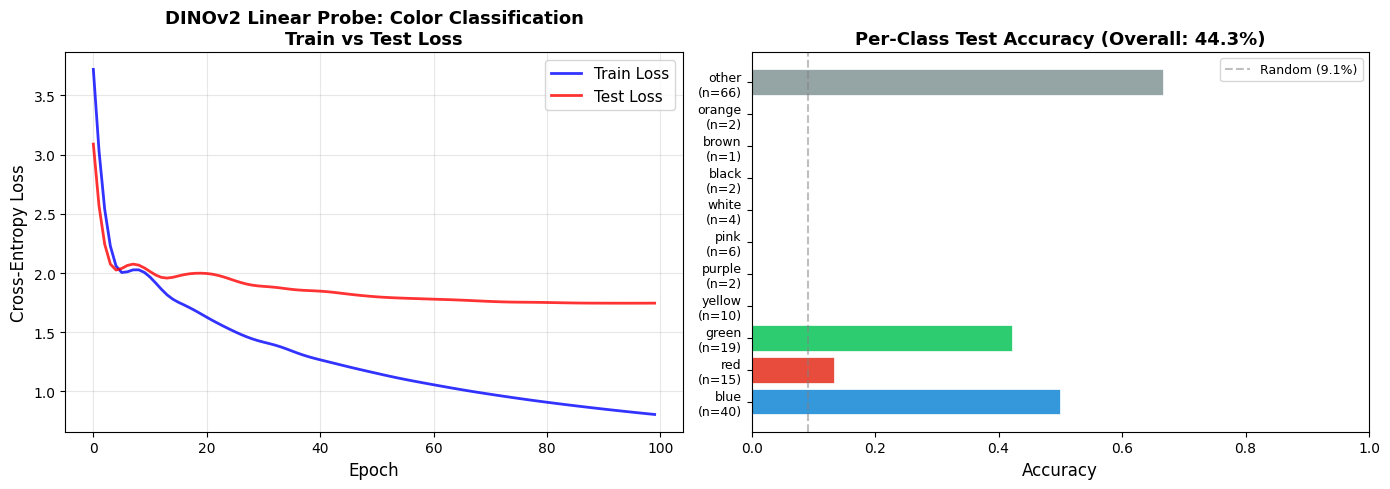

In [23]:
# Plot DINOv2 linear probe loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(dino_train_losses, 'b-', label='Train Loss', linewidth=2, alpha=0.8)
ax1.plot(dino_test_losses, 'r-', label='Test Loss', linewidth=2, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('DINOv2 Linear Probe: Color Classification\nTrain vs Test Loss',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Per-class accuracy bar chart
class_accs = []
class_names_plot = []
bar_colors = []
for i, name in enumerate(color_categories + ['other']):
    mask = test_labels == i
    if mask.sum() > 0:
        acc = (final_preds[mask] == test_labels[mask]).float().mean().item()
        class_accs.append(acc)
        class_names_plot.append(f"{name}\n(n={mask.sum()})")
        bar_colors.append(color_map.get(name, '#95a5a6'))

y_pos = range(len(class_accs))
ax2.barh(y_pos, class_accs, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(class_names_plot, fontsize=9)
ax2.set_xlabel('Accuracy', fontsize=12)
ax2.set_xlim(0, 1)
ax2.set_title(f'Per-Class Test Accuracy (Overall: {final_acc:.1%})',
              fontsize=13, fontweight='bold')
ax2.axvline(x=1.0/n_classes, color='gray', linestyle='--', alpha=0.5, label=f'Random ({1.0/n_classes:.1%})')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

<a id="comparison"></a>

---

# Part 3: CLIP vs DINOv2 — Side-by-Side Comparison

Now let's directly compare what each model learned. We'll look at:

1. **Feature space structure** — t-SNE visualization side by side
2. **Retrieval** — same intent, different approaches (CLIP uses text, DINOv2 uses an image)

Remember the fundamental difference:
- **CLIP** was trained with images **and** text → understands language-visual alignment
- **DINOv2** was trained with images **only** → understands visual similarity

These are **complementary**, not competing.

Running t-SNE on CLIP features...


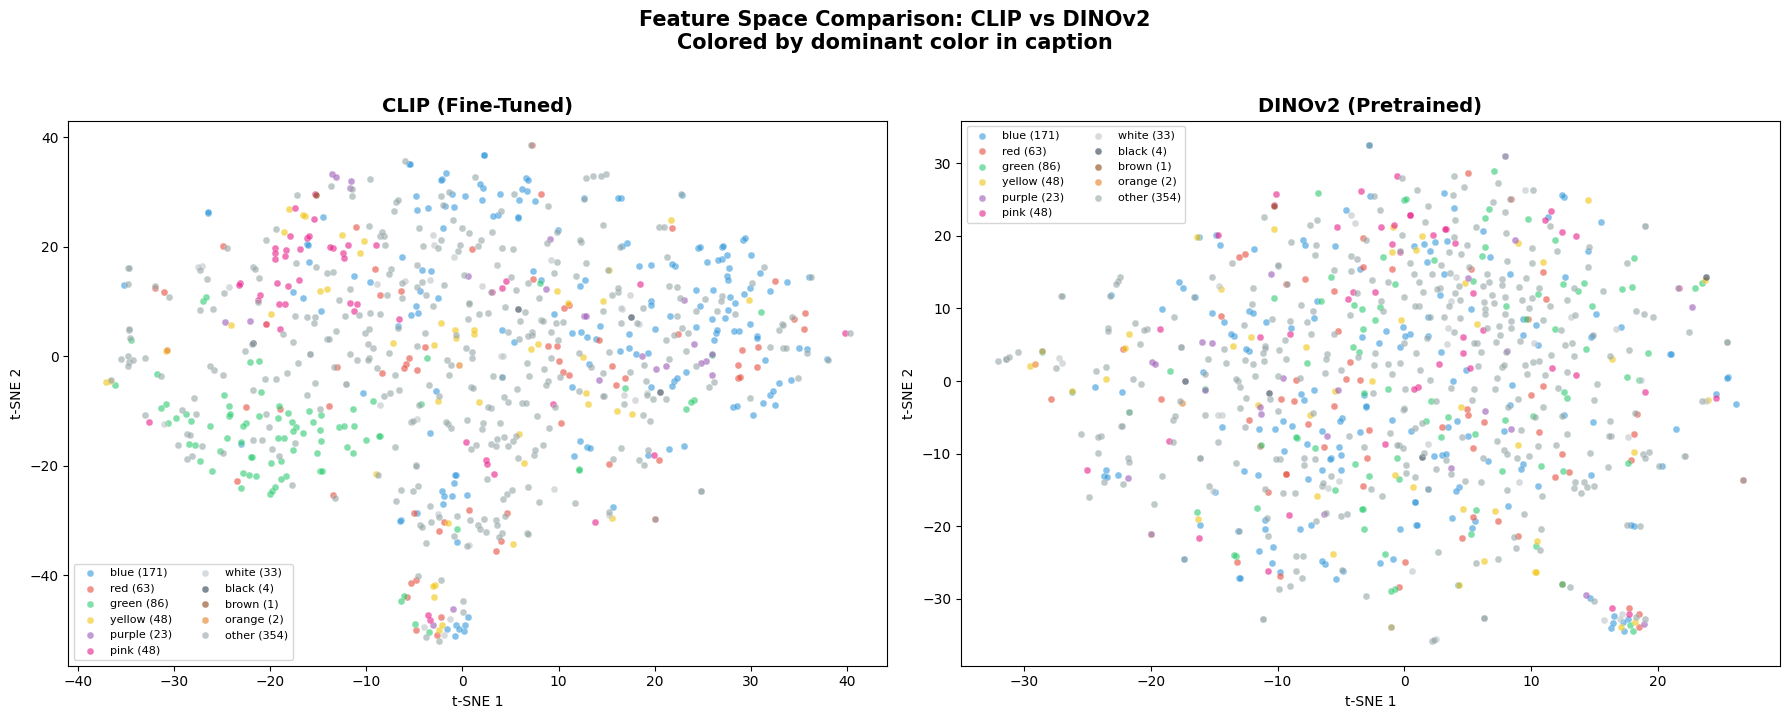

In [24]:
# Side-by-side t-SNE: CLIP vs DINOv2
print("Running t-SNE on CLIP features...")
clip_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    all_clip_features.numpy()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, coords, title in [(ax1, clip_2d, "CLIP (Fine-Tuned)"),
                           (ax2, dino_2d, "DINOv2 (Pretrained)")]:
    for color_name in list(color_map.keys()) + ['other']:
        hex_color = color_map.get(color_name, '#95a5a6')
        mask = np.array([c == color_name for c in color_labels])
        n = mask.sum()
        if n > 0:
            ax.scatter(coords[mask, 0], coords[mask, 1], c=hex_color,
                       label=f"{color_name} ({n})", alpha=0.6, s=25,
                       edgecolors='white', linewidth=0.3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=8, ncol=2, loc='best')

plt.suptitle("Feature Space Comparison: CLIP vs DINOv2\nColored by dominant color in caption",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

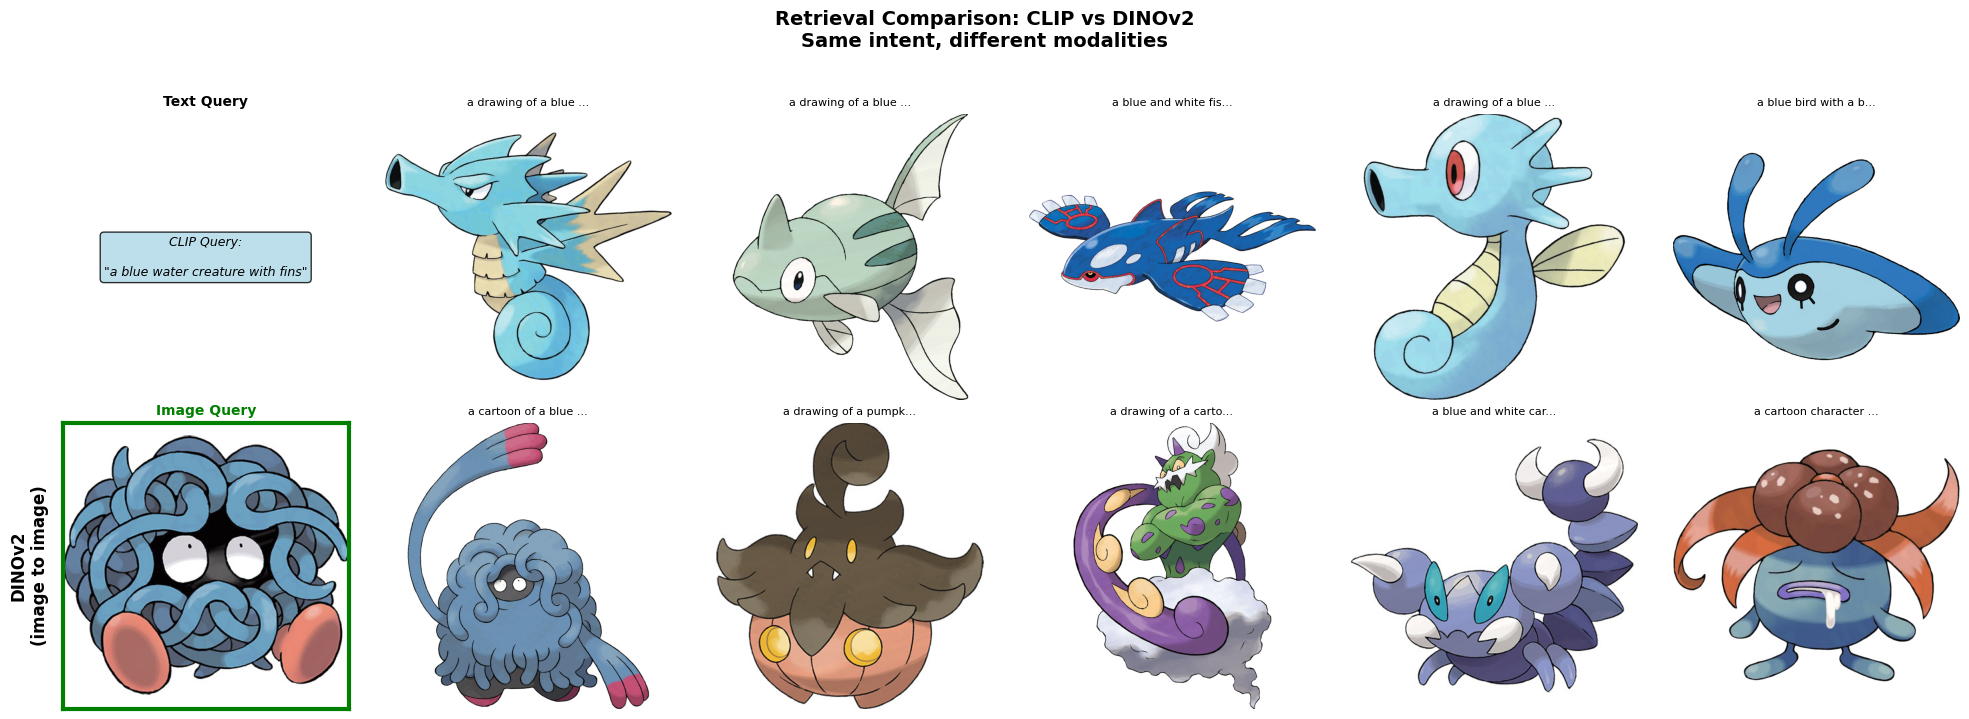

In [25]:
# Retrieval comparison
# CLIP: text query → images
# DINOv2: image query → images

# Find a blue pokemon for the DINOv2 query
blue_indices = [i for i, c in enumerate(color_labels) if c == 'blue']
dino_query_idx = blue_indices[0] if blue_indices else 0

query_text = "a blue water creature with fins"

# --- CLIP: text → image ---
text_inputs = clip_processor(text=[query_text], return_tensors="pt", padding=True).to(device)
clip_model.eval()
with torch.no_grad():
    text_feat = clip_model.get_text_features(**text_inputs)
    if not isinstance(text_feat, torch.Tensor):
        text_feat = text_feat.pooler_output
    text_feat = F.normalize(text_feat, dim=-1)

clip_sims = (text_feat.cpu() @ all_clip_features.T)[0]
clip_top5 = clip_sims.topk(5).indices.tolist()

# --- DINOv2: image → image ---
dino_query = all_dino_features[dino_query_idx]
dino_sims = F.cosine_similarity(dino_query.unsqueeze(0), all_dino_features)
dino_sims[dino_query_idx] = -1
dino_top5 = dino_sims.topk(5).indices.tolist()

# Visualize
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

# Row 0: CLIP text-to-image
axes[0, 0].text(0.5, 0.5, f'CLIP Query:\n\n"{query_text}"',
                ha='center', va='center', fontsize=9, style='italic',
                transform=axes[0, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[0, 0].axis('off')
axes[0, 0].set_title("Text Query", fontsize=10, fontweight='bold')

for col, idx in enumerate(clip_top5):
    axes[0, col + 1].imshow(full_dataset[idx]['image'].convert('RGB'))
    cap = full_dataset[idx]['text']
    axes[0, col + 1].set_title(cap[:20] + "..." if len(cap) > 20 else cap, fontsize=8)
    axes[0, col + 1].axis('off')

# Row 1: DINOv2 image-to-image
axes[1, 0].imshow(full_dataset[dino_query_idx]['image'].convert('RGB'))
axes[1, 0].set_title("Image Query", fontsize=10, fontweight='bold', color='green')
for spine in axes[1, 0].spines.values():
    spine.set_visible(True)
    spine.set_color('green')
    spine.set_linewidth(3)
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

for col, idx in enumerate(dino_top5):
    axes[1, col + 1].imshow(full_dataset[idx]['image'].convert('RGB'))
    cap = full_dataset[idx]['text']
    axes[1, col + 1].set_title(cap[:20] + "..." if len(cap) > 20 else cap, fontsize=8)
    axes[1, col + 1].axis('off')

# Row labels
axes[0, 0].set_ylabel("CLIP\n(text to image)", fontsize=12, fontweight='bold', labelpad=10)
axes[1, 0].set_ylabel("DINOv2\n(image to image)", fontsize=12, fontweight='bold', labelpad=10)

plt.suptitle("Retrieval Comparison: CLIP vs DINOv2\nSame intent, different modalities",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary and Key Takeaways

### What We Learned

**CLIP (Contrastive Language-Image Pretraining):**
- Aligns images and text in a shared embedding space via contrastive learning
- Enables zero-shot classification and text-to-image retrieval
- Fine-tuning on domain data (Pokemon) strengthens the alignment
- Best when you need **language-guided** understanding of images

**DINOv2 (Self-Distillation with No Labels v2):**
- Learns powerful visual features using only images — no text required
- Uses a teacher-student self-distillation framework with multiple crops
- Produces rich features suitable for classification, retrieval, and segmentation
- Best when you need **strong visual representations** for downstream tasks

### When to Use Which?

| Scenario | Best Choice | Why |
|---|---|---|
| Text-based image search | **CLIP** | Natively aligns text and images |
| Zero-shot classification | **CLIP** | Can classify using text prompts |
| Finding visually similar images | **DINOv2** | Stronger visual similarity features |
| Feature extraction for downstream ML | **DINOv2** | Better linear probe performance |
| When you only have images (no text) | **DINOv2** | No text supervision needed |
| When you have image-text pairs | **CLIP** | Can leverage the text signal |

### The Bigger Picture

Both approaches demonstrate the power of **self-supervised learning**: training strong encoders from data alone, then reusing them everywhere. This "train once, use everywhere" paradigm is especially valuable in domains like medicine, where labeled data is scarce but raw images are plentiful.

### References

- Chen et al., [SimCLR: A Simple Framework for Contrastive Learning](https://arxiv.org/abs/2002.05709), ICML 2020
- Radford et al., [CLIP: Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020), ICML 2021
- Caron et al., [Emerging Properties in Self-Supervised Vision Transformers (DINO)](https://arxiv.org/abs/2104.14294), 2021
- Oquab et al., [DINOv2: Learning Robust Visual Features without Supervision](https://arxiv.org/abs/2304.07193), 2023